In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()

Saving data.csv to data.csv


In [3]:
df=pd.read_csv("data.csv", encoding="ISO-8859-1")

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [10]:
df.drop(columns=["StockCode", "Description", "Country"], inplace=True)

In [11]:
df.head()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,6,12/1/2010 8:26,2.55,17850.0
1,536365,6,12/1/2010 8:26,3.39,17850.0
2,536365,8,12/1/2010 8:26,2.75,17850.0
3,536365,6,12/1/2010 8:26,3.39,17850.0
4,536365,6,12/1/2010 8:26,3.39,17850.0


In [12]:
df.dropna(subset=["CustomerID"], inplace=True)

In [13]:
df.isnull().sum()

,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0


In [14]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [15]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8905)

In [16]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

In [17]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [18]:
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())
print("Invalid UnitPrice:", (df["UnitPrice"] <= 0).sum())

Invalid Quantity: 0
Invalid UnitPrice: 40


In [19]:
df = df[
    (df["UnitPrice"] > 0)
].copy()

In [20]:
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())
print("Invalid UnitPrice:", (df["UnitPrice"] <= 0).sum())

Invalid Quantity: 0
Invalid UnitPrice: 0


In [21]:
df.shape

(397884, 5)

In [22]:
df.duplicated().sum()

np.int64(150457)

In [23]:
df.drop_duplicates(inplace=True)
df.shape

(247427, 5)

In [24]:
df['InvoiceDate'].dtype

dtype('O')

In [25]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
5,2010-12-01 08:26:00
6,2010-12-01 08:26:00
...,...
541901,2011-12-09 12:50:00
541903,2011-12-09 12:50:00
541904,2011-12-09 12:50:00
541905,2011-12-09 12:50:00


In [26]:
print("Starting date:", df["InvoiceDate"].min())
print("Ending date:", df["InvoiceDate"].max())

Starting date: 2010-12-01 08:26:00
Ending date: 2011-12-09 12:50:00


In [27]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
0,536365,6,2010-12-01 08:26:00,2.55,17850,15.30
1,536365,6,2010-12-01 08:26:00,3.39,17850,20.34
2,536365,8,2010-12-01 08:26:00,2.75,17850,22.00
5,536365,2,2010-12-01 08:26:00,7.65,17850,15.30
6,536365,6,2010-12-01 08:26:00,4.25,17850,25.50


In [28]:
df["TotalPrice"].describe()

,TotalPrice
count,247427.000000
mean,26.892201
std,390.451949
min,0.001000
25%,5.850000
50%,13.500000
75%,20.800000
max,168469.600000


In [29]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [30]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda date: (reference_date - date.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

In [31]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

In [32]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,3125.98
2,12348,75,4,1399.80
3,12349,19,1,1209.49
4,12350,310,1,174.20


In [33]:
rfm.shape

(4338, 4)

In [34]:
rfm.isnull().sum()

,0
CustomerID,0
Recency,0
Frequency,0
Monetary,0


In [35]:
rfm.duplicated().sum()

np.int64(0)

In [36]:
rfm["CustomerID"].duplicated().sum()

np.int64(0)

In [37]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,1533.853512
std,100.014169,7.697998,6988.432429
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,221.825000
50%,51.000000,2.000000,495.930000
75%,142.000000,5.000000,1188.825000
max,374.000000,209.000000,202359.830000


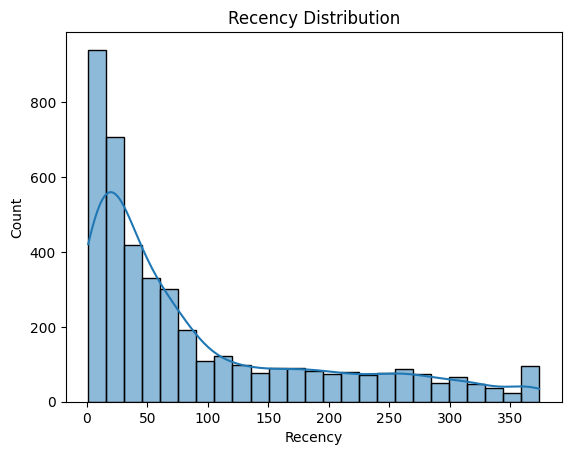

In [38]:
sns.histplot(rfm["Recency"], kde=True)
plt.title("Recency Distribution")
plt.show()

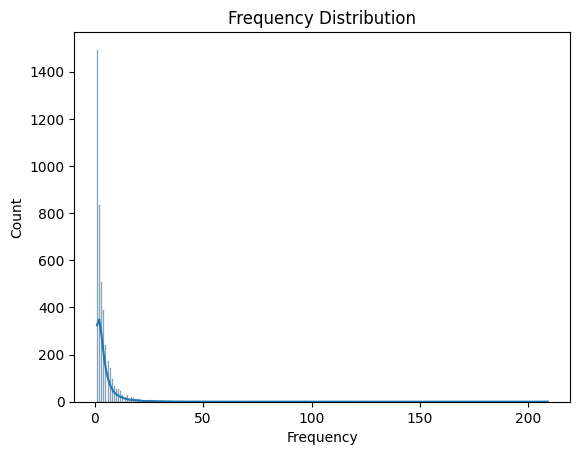

In [39]:
sns.histplot(rfm["Frequency"], kde=True)
plt.title("Frequency Distribution")
plt.show()

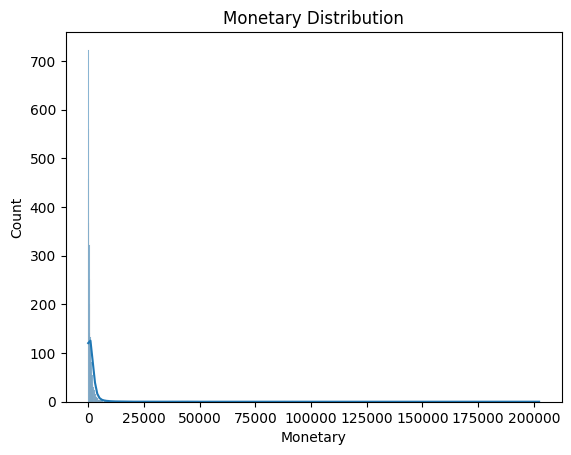

In [40]:
sns.histplot(rfm["Monetary"], kde=True)
plt.title("Monetary Distribution")
plt.show()

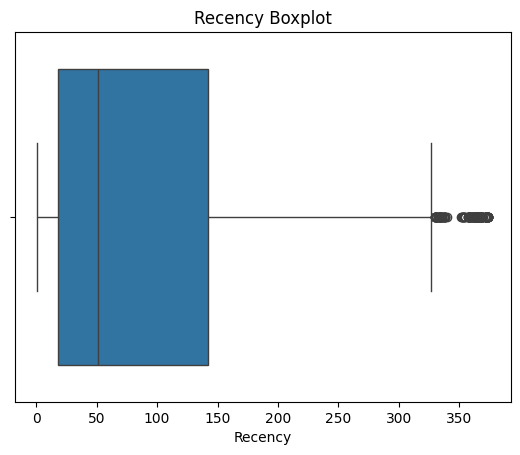

In [41]:
sns.boxplot(x=rfm["Recency"])
plt.title("Recency Boxplot")
plt.show()

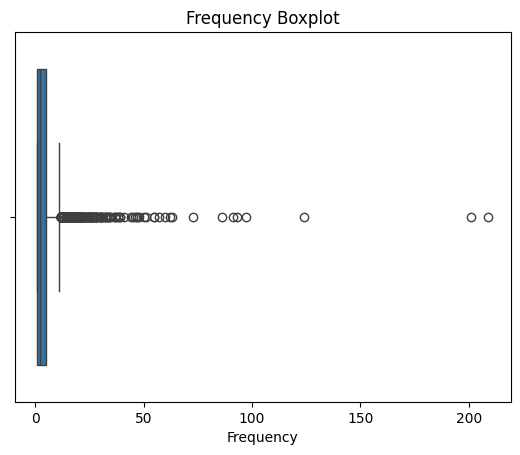

In [42]:
sns.boxplot(x=rfm["Frequency"])
plt.title("Frequency Boxplot")
plt.show()

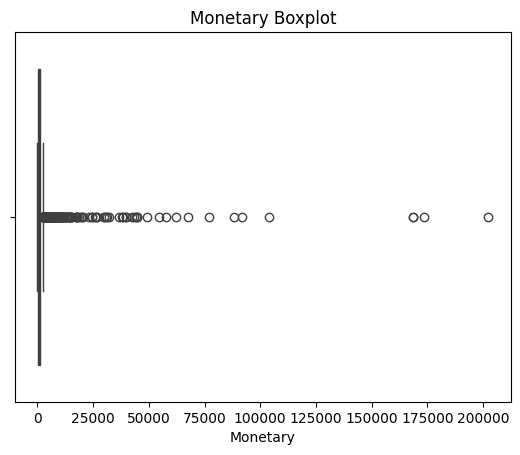

In [43]:
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Boxplot")
plt.show()

In [44]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

In [45]:
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [46]:
rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.047823
2,4.330733,1.609438,7.244799
3,2.995732,0.693147,7.098781
4,5.739793,0.693147,5.165928


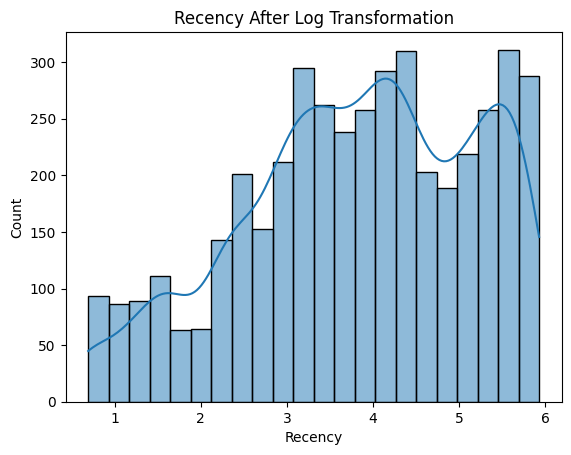

In [47]:
sns.histplot(rfm_log["Recency"], kde=True)
plt.title("Recency After Log Transformation")
plt.show()

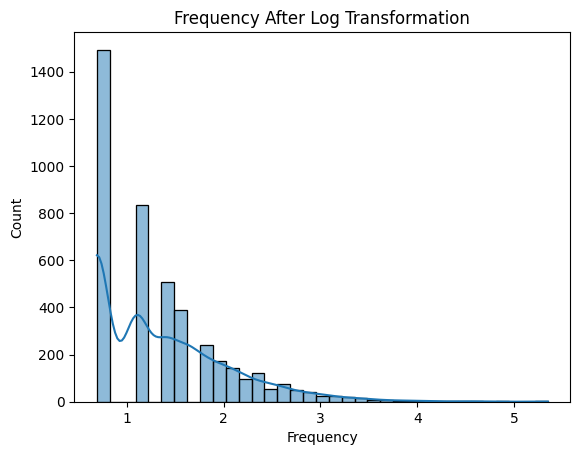

In [48]:
sns.histplot(rfm_log["Frequency"], kde=True)
plt.title("Frequency After Log Transformation")
plt.show()

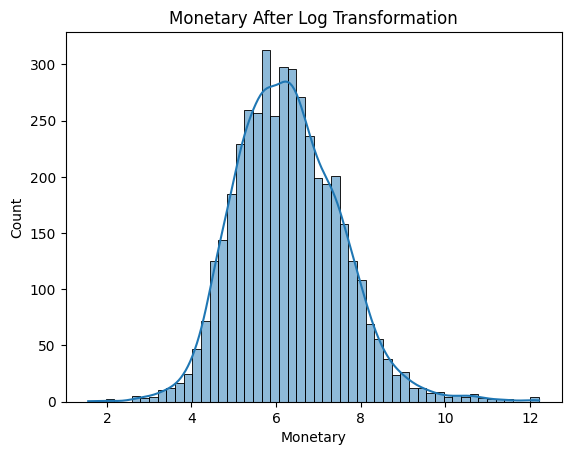

In [49]:
sns.histplot(rfm_log["Monetary"], kde=True)
plt.title("Monetary After Log Transformation")
plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [51]:
rfm_scaled = scaler.fit_transform(rfm_log)

In [52]:
rfm_scaled=pd.DataFrame(rfm_scaled, columns=rfm_log.columns)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,4.010258
1,-2.038734,1.074425,1.423725
2,0.373104,0.386304,0.775889
3,-0.623086,-0.955214,0.658089
4,1.424558,-0.955214,-0.901231


In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
k_values = range(2, 11)

inertia_values = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

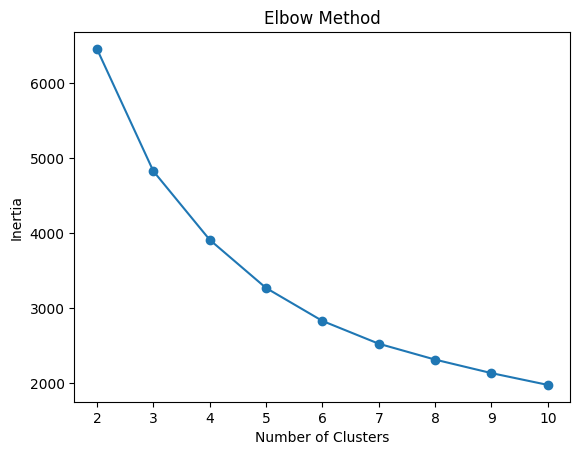

In [54]:
plt.plot(range(2, 11), inertia_values, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [55]:
for k, score in zip(range(2, 11), silhouette_scores):
    print("k =", k, "| Score =", round(score, 4))

k = 2 | Score = 0.4362
k = 3 | Score = 0.3415
k = 4 | Score = 0.3378
k = 5 | Score = 0.32
k = 6 | Score = 0.3168
k = 7 | Score = 0.3111
k = 8 | Score = 0.3057
k = 9 | Score = 0.2821
k = 10 | Score = 0.2815


In [56]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

In [57]:
cluster_labels = kmeans.fit_predict(rfm_scaled)

In [58]:
rfm["Cluster"] = cluster_labels

In [59]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,3125.98,1
2,12348,75,4,1399.80,2
3,12349,19,1,1209.49,2
4,12350,310,1,174.20,0


In [60]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,1912
2,1677
1,749


In [61]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,165.360879,1.358264,268.553165
1,16.416555,13.546061,6102.604927
2,43.504472,3.451998,935.916394


In [62]:
cluster_summary["CustomerCount"] = rfm.groupby("Cluster")[
    "CustomerID"
].count()
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,165.360879,1.358264,268.553165,1912
1,16.416555,13.546061,6102.604927,749
2,43.504472,3.451998,935.916394,1677


In [63]:
cluster_summary.head()

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,165.360879,1.358264,268.553165,1912
1,16.416555,13.546061,6102.604927,749
2,43.504472,3.451998,935.916394,1677


In [64]:
cluster_names = {
    0: "At-Risk Customers",
    1: "High-Value Customers",
    2: "Regular Customers"
}

In [65]:
rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_names)

In [66]:
rfm["CustomerSegment"].value_counts()

,count
CustomerSegment,
At-Risk Customers,1912
Regular Customers,1677
High-Value Customers,749


In [67]:
segment_counts = rfm["CustomerSegment"].value_counts()

segment_counts

,count
CustomerSegment,
At-Risk Customers,1912
Regular Customers,1677
High-Value Customers,749


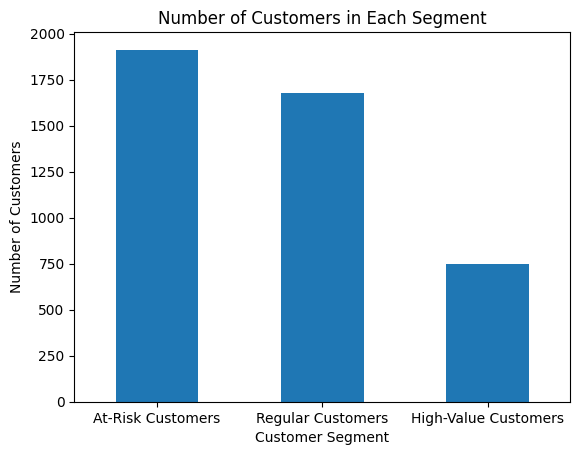

In [68]:
segment_counts.plot(kind="bar")

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [69]:
segment_summary = rfm.groupby("CustomerSegment")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(2)

segment_summary

,Recency,Frequency,Monetary
CustomerSegment,,,
At-Risk Customers,165.36,1.36,268.55
High-Value Customers,16.42,13.55,6102.60
Regular Customers,43.50,3.45,935.92


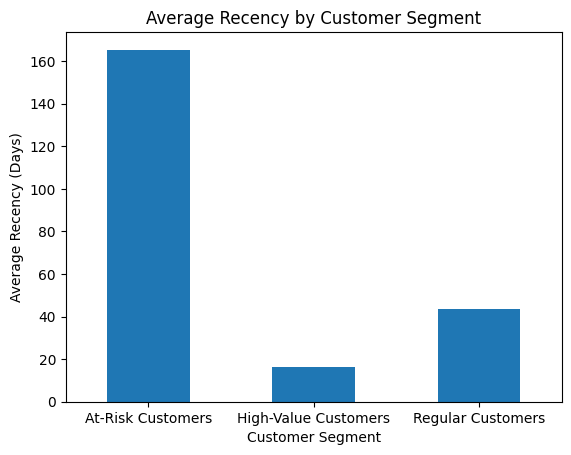

In [70]:
segment_summary["Recency"].plot(kind="bar")

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.xticks(rotation=0)

plt.show()

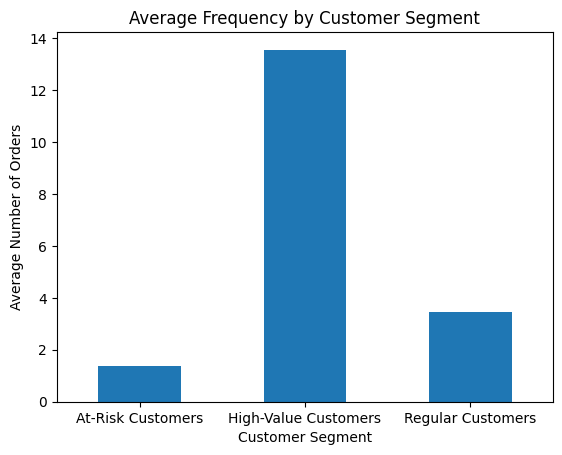

In [71]:
segment_summary["Frequency"].plot(kind="bar")

plt.title("Average Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Orders")
plt.xticks(rotation=0)

plt.show()

In [84]:
def predict_customer_segment(
    recency,
    frequency,
    monetary
):
    new_customer = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary]
    })

    # Same log transformation
    new_customer_log = np.log1p(
        new_customer
    )

    # Same trained scaler
    new_customer_scaled = scaler.transform(
        new_customer_log
    )

    new_customer_scaled = pd.DataFrame(
        new_customer_scaled,
        columns=[
            "Recency",
            "Frequency",
            "Monetary"
        ]
    )

    # Current trained model
    cluster = kmeans.predict(
        new_customer_scaled
    )[0]

    segment = cluster_names[cluster]

    return cluster, segment

In [86]:
print(predict_customer_segment(
    recency=10,
    frequency=15,
    monetary=5000
))

(np.int32(1), 'High-Value Customers')


In [77]:
import joblib
model_bundle = {
    "model": kmeans,
    "scaler": scaler,
    "cluster_names": cluster_names,
    "features": [
        "Recency",
        "Frequency",
        "Monetary"
    ]
}

In [79]:
rfm.to_csv(
    "customer_segments.csv",
    index=False
)

In [78]:
joblib.dump(
    model_bundle,
    "customer_segmentation_model.pkl"
)

['customer_segmentation_model.pkl']

In [80]:
import os
print(os.path.exists("customer_segmentation_model.pkl"))
print(os.path.exists("customer_segments.csv"))

True
True


In [87]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib


st.set_page_config(
    page_title="Customer Segmentation",
    page_icon="👥",
    layout="centered"
)


@st.cache_resource
def load_model():
    bundle = joblib.load(
        "customer_segmentation_model.pkl"
    )
    return bundle


bundle = load_model()

model = bundle["model"]
scaler = bundle["scaler"]
cluster_names = bundle["cluster_names"]
features = bundle["features"]


st.title("Customer Segmentation System")

st.write(
    "Enter the customer's purchasing behaviour "
    "to identify their segment."
)


recency = st.number_input(
    "Recency (days since last purchase)",
    min_value=0,
    value=30,
    step=1
)

frequency = st.number_input(
    "Frequency (number of orders)",
    min_value=1,
    value=5,
    step=1
)

monetary = st.number_input(
    "Monetary (total customer spending)",
    min_value=0.01,
    value=1000.00,
    step=100.00
)


if st.button(
    "Predict Customer Segment",
    type="primary"
):
    new_customer = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary]
    })

    new_customer_log = np.log1p(
        new_customer
    )

    new_customer_scaled = scaler.transform(
        new_customer_log
    )

    new_customer_scaled = pd.DataFrame(
        new_customer_scaled,
        columns=features
    )

    cluster = model.predict(
        new_customer_scaled
    )[0]

    segment = cluster_names[cluster]

    st.success(
        f"Customer Segment: {segment}"
    )

    st.write(
        f"Cluster Number: {cluster}"
    )

    if segment == "High-Value Customers":
        st.info(
            "This customer purchases frequently, "
            "spends more and has purchased recently."
        )

    elif segment == "Regular Customers":
        st.info(
            "This customer has moderate purchasing "
            "frequency and spending."
        )

    else:
        st.warning(
            "This customer has not purchased recently "
            "and may require a re-engagement campaign."
        )

Writing app.py


In [88]:
%%writefile requirements.txt

streamlit
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.5.3

Writing requirements.txt


In [89]:
!zip -r customer-segmentation.zip \
app.py \
customer_segmentation_model.pkl \
customer_segments.csv \
requirements.txt

  adding: app.py (deflated 62%)
  adding: customer_segmentation_model.pkl (deflated 85%)
  adding: customer_segments.csv (deflated 77%)
  adding: requirements.txt (deflated 8%)


In [90]:
files.download(
    "customer-segmentation.zip"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>